# Fileless Malware Detection Using Explainable Machine Learning
## Memory Forensics-Based Analysis on CIC-MalMem-2022 Dataset

**Author:** Ahmed Mahmoud Mohamed  
**Role:** Teaching Assistant, Dept. of Information Technology  
**Institution:** Faculty of Computers and Information, Luxor University  
**Thesis:** Automated Triage of Fileless Malware in Windows Environments Using XAI & Memory Forensics

---

### Pipeline Overview
```
Phase 0 → Imports & Configuration
Phase 1 → Data Loading & Integrity Validation
Phase 2 → Exploratory Data Analysis (EDA)
Phase 3 → Preprocessing & Feature Engineering
Phase 4 → Model Training (XGBoost)
Phase 5 → Rigorous Evaluation (Hold-out + CV + Overfitting Gap)
Phase 6 → Explainability (SHAP global + LIME local)
Phase 7 → Model Comparison
Phase 8 → Data Integrity & Leakage Audit  ← REVIEWER FIXES APPLIED HERE
Phase 9 → Artifact Export
```

### Reviewer Fixes Applied (v3)
```
[FIX 1] Permutation test: n_permutations 20 → 1000, with p-value formula documented
[FIX 2] Overlap audit: run on RAW data AND post-clean data separately, denominator fixed
[FIX 3] SHAP output space documented: TreeExplainer uses raw margin (log-odds)
[FIX 4] LIME: inverse-transform thresholds back to original feature units for interpretability
[FIX 5] Noise test: reworded as 'synthetic feature perturbation' — not operational noise claim
[FIX 6] Overfitting conclusion: qualified language ('no evidence') not absolute
```

---
## Phase 0 — Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# STANDARD LIBRARY
# ─────────────────────────────────────────────────────────────────────────────
import warnings
import os
import time

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# DATA & MATH
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────────────
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    permutation_test_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

# Persistence
import joblib

# ─────────────────────────────────────────────────────────────────────────────
# EXPLAINABILITY (XAI)
# ─────────────────────────────────────────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_STATE        = 42       # Reproducibility seed
TEST_SIZE           = 0.20     # 80/20 train-test split
N_FOLDS             = 5        # Stratified k-fold CV
SHAP_SAMPLE         = 500      # Max samples for SHAP (for performance)
LIME_FEATURES       = 10       # Top features shown in LIME explanation
N_PERMUTATIONS      = 1000     # [FIX 1] Increased from 20 → 1000 for robust p-value
DATASET_PATH        = 'MalMem2022.csv'
OUTPUT_DIR          = 'outputs/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Publication-quality figure settings
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

print('[✓] All imports successful.')
print(f'[✓] XGBoost version : {xgb.__version__}')
print(f'[✓] Permutation test: n_permutations = {N_PERMUTATIONS}')
print(f'[✓] Output directory: {os.path.abspath(OUTPUT_DIR)}')

[✓] All imports successful.
[✓] XGBoost version : 3.2.0
[✓] Permutation test: n_permutations = 1000
[✓] Output directory: C:\Users\Ahmed El-khatib\Data Set\outputs


---
## Phase 1 — Data Loading & Integrity Validation

In [2]:
print('[*] Loading CIC-MalMem-2022 Dataset...')

df_raw = pd.read_csv(DATASET_PATH)

print(f'[✓] Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

print('\n' + '─' * 55)
print(' DATA INTEGRITY REPORT (RAW DATASET)')
print('─' * 55)

# Class distribution
class_counts = df_raw['Class'].value_counts()
print('\n[Class Distribution]')
for cls, cnt in class_counts.items():
    pct = cnt / len(df_raw) * 100
    print(f'  {cls:<10} : {cnt:>6,} samples  ({pct:.1f}%)')

# Missing values
missing_total = df_raw.isnull().sum().sum()
print(f'\n[Missing Values]  : {missing_total}')

# Duplicate rows in raw data
dup_count = df_raw.duplicated().sum()
print(f'[Duplicate Rows]  : {dup_count}  ← will be removed before split')

# Non-numeric columns
non_numeric = df_raw.select_dtypes(exclude='number').columns.tolist()
print(f'[Non-numeric Cols]: {non_numeric}')

print('\n[Sample Preview]')
display(df_raw.head(3))

[*] Loading CIC-MalMem-2022 Dataset...
[✓] Loaded: 58,596 rows × 58 columns

───────────────────────────────────────────────────────
 DATA INTEGRITY REPORT (RAW DATASET)
───────────────────────────────────────────────────────

[Class Distribution]
  Benign     : 29,298 samples  (50.0%)
  Malware    : 29,298 samples  (50.0%)

[Missing Values]  : 0
[Duplicate Rows]  : 534  ← will be removed before split
[Non-numeric Cols]: ['Class', 'Category', 'Filename']

[Sample Preview]


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.50000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.12766,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.30000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign


---
## Phase 2 — Exploratory Data Analysis (EDA)

[*] Generating EDA visualizations...


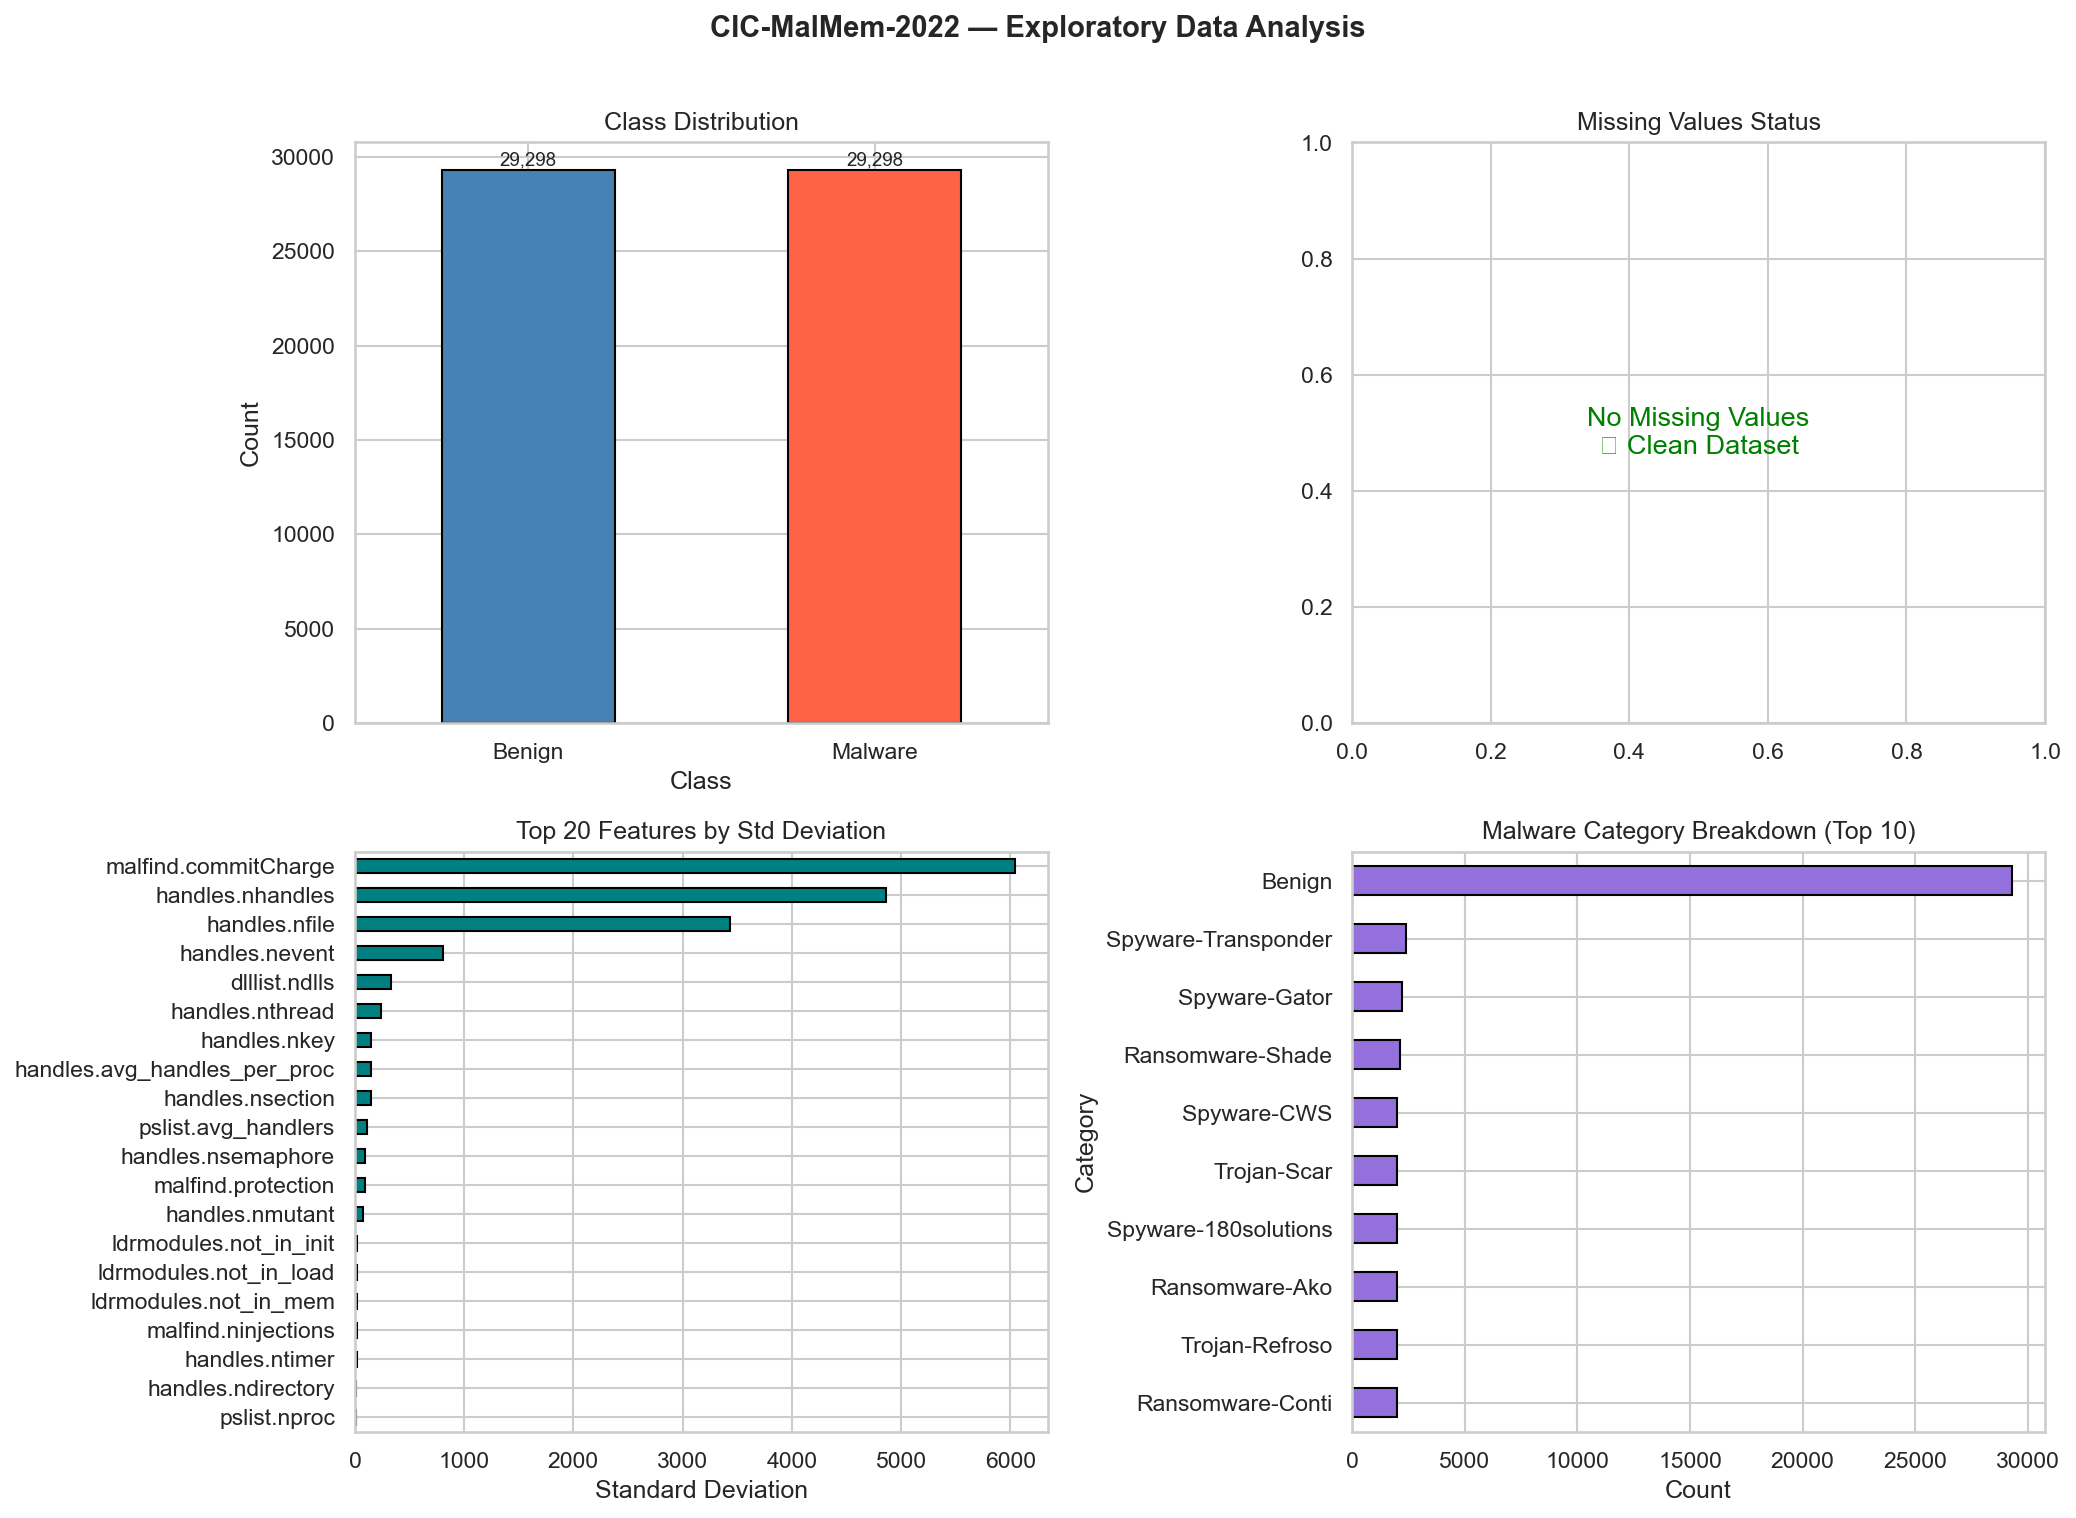

[✓] EDA dashboard saved.


In [3]:
print('[*] Generating EDA visualizations...')

numeric_df = df_raw.select_dtypes(include='number')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CIC-MalMem-2022 — Exploratory Data Analysis',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Class Distribution
ax1 = axes[0, 0]
class_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'], edgecolor='black')
ax1.set_title('Class Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for bar, val in zip(ax1.patches, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# Plot 2: Missing values
ax2 = axes[0, 1]
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False).head(20)
if missing_pct.sum() > 0:
    missing_pct.plot(kind='bar', ax=ax2, color='salmon', edgecolor='black')
    ax2.set_title('Missing Values (Top 20 Features)')
    ax2.set_ylabel('Missing %')
else:
    ax2.text(0.5, 0.5, 'No Missing Values\n✓ Clean Dataset',
             ha='center', va='center', fontsize=13, color='green',
             transform=ax2.transAxes)
    ax2.set_title('Missing Values Status')

# Plot 3: Std deviation across features
ax3 = axes[1, 0]
std_vals = numeric_df.std().sort_values(ascending=False).head(20)
std_vals.plot(kind='barh', ax=ax3, color='teal', edgecolor='black')
ax3.set_title('Top 20 Features by Std Deviation')
ax3.set_xlabel('Standard Deviation')
ax3.invert_yaxis()

# Plot 4: Malware category breakdown
ax4 = axes[1, 1]
if 'Category' in df_raw.columns:
    cat_counts = df_raw['Category'].value_counts().head(10)
    cat_counts.plot(kind='barh', ax=ax4, color='mediumpurple', edgecolor='black')
    ax4.set_title('Malware Category Breakdown (Top 10)')
    ax4.set_xlabel('Count')
    ax4.invert_yaxis()
else:
    ax4.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_dashboard.png', bbox_inches='tight')
plt.show()
print('[✓] EDA dashboard saved.')

In [ ]:
# Feature-target correlation on RAW data (before any cleaning)
df_corr = df_raw.copy()
df_corr['Class_bin'] = df_corr['Class'].map({'Benign': 0, 'Malware': 1})

correlations = (
    df_corr
    .select_dtypes(include='number')
    .corr()['Class_bin']
    .drop('Class_bin')
    .abs()
    .sort_values(ascending=False)
)

print('[*] Top 20 Features Correlated with Target (|r|) — on RAW dataset:')
print(correlations.head(20).to_string())

# Flag near-perfect correlations (potential proxy leakage)
leakage_suspects = correlations[correlations > 0.95].index.tolist()
if leakage_suspects:
    print(f'\n[⚠️  WARNING] Features with |r| > 0.95 — possible proxy leakage:')
    for f in leakage_suspects:
        print(f'  → {f}  (|r| = {correlations[f]:.4f})')
else:
    print('\n[✓] No features with |r| > 0.95 detected.')

---
## Phase 3 — Preprocessing & Feature Engineering

**Pipeline order (important for audit consistency):**
1. Drop duplicates from raw data
2. Encode target
3. Remove zero-variance features
4. Stratified train/test split
5. Fit StandardScaler on train only → transform both sets

> **Note:** Duplicate removal happens *before* the split.  
> The overlap audit in Phase 8 therefore operates on the post-clean split  
> and should produce zero exact duplicates across boundaries.

In [4]:
print('[*] Preprocessing pipeline...')

# ── Step 1: Clean & Deduplicate (BEFORE split)
df = df_raw.copy()
n_before = len(df)
df = df.dropna().drop_duplicates().reset_index(drop=True)
n_after  = len(df)
print(f'[✓] Removed {n_before - n_after} duplicates. After cleaning: {n_after:,} rows')

# ── Step 2: Encode target
#   Benign  → 0 | Malware → 1
df['Class_bin'] = df['Class'].map({'Benign': 0, 'Malware': 1})
assert df['Class_bin'].isnull().sum() == 0, 'Encoding failed!'

benign_n  = (df.Class_bin == 0).sum()
malware_n = (df.Class_bin == 1).sum()
print(f'[✓] Target encoded: Benign=0 ({benign_n:,})  |  Malware=1 ({malware_n:,})')
# Note: near-balanced (not perfectly balanced) after deduplication
print(f'    Class ratio: {benign_n/n_after*100:.1f}% Benign / {malware_n/n_after*100:.1f}% Malware')

# ── Step 3: Define feature matrix
META_COLS   = ['Category', 'Class', 'Filename', 'Class_bin']
feature_cols = [
    col for col in df.columns
    if col not in META_COLS
    and pd.api.types.is_numeric_dtype(df[col])
]

X = df[feature_cols].values.astype(np.float32)
y = df['Class_bin'].values
print(f'[✓] Feature matrix shape: {X.shape}')

# ── Step 4: Remove zero-variance features
#   Constant features carry no discriminative power
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X)
removed = X.shape[1] - X_vt.shape[1]
feature_cols = [f for f, keep in zip(feature_cols, vt.get_support()) if keep]
X = X_vt
print(f'[✓] Removed {removed} zero-variance features. Remaining: {len(feature_cols)}')

# Store raw (unscaled) feature values for LIME inverse-transform
# We need these to convert scaled thresholds back to original units
X_raw_df = pd.DataFrame(X, columns=feature_cols)  # unscaled, for reference

# ── Step 5: Stratified train/test split
#   stratify=y → preserves class proportions in both partitions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f'[✓] Train set : {X_train.shape[0]:,} samples')
print(f'[✓] Test set  : {X_test.shape[0]:,} samples')

# ── Step 6: Feature scaling
#   CRITICAL: fit on X_train ONLY — prevents test distribution leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Store scaler statistics for LIME inverse-transform (used in Phase 6)
feature_means  = scaler.mean_
feature_stds   = scaler.scale_

print('[✓] Feature scaling applied (StandardScaler — zero mean, unit variance).')
print('[✓] Preprocessing complete.')

[*] Preprocessing pipeline...
[✓] Removed 534 duplicates. After cleaning: 58,062 rows
[✓] Target encoded: Benign=0 (29,231)  |  Malware=1 (28,831)
    Class ratio: 50.3% Benign / 49.7% Malware
[✓] Feature matrix shape: (58062, 55)
[✓] Removed 3 zero-variance features. Remaining: 52
[✓] Train set : 46,449 samples
[✓] Test set  : 11,613 samples
[✓] Feature scaling applied (StandardScaler — zero mean, unit variance).
[✓] Preprocessing complete.


---
## Phase 4 — Model Training (XGBoost)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBOOST HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# n_estimators    = 300  → sufficient trees for convergence on this dataset
# max_depth       = 5    → moderately complex; avoids memorising noise
# learning_rate   = 0.05 → conservative step; improves generalisation
# subsample       = 0.8  → row subsampling; reduces variance
# colsample_bytree= 0.8  → column subsampling per tree
# reg_lambda      = 1.0  → L2 regularisation on leaf weights
# reg_alpha       = 0.1  → L1 regularisation; sparse feature usage
# min_child_weight= 5    → min samples per leaf; prevents noisy splits
# gamma           = 0.1  → minimum loss reduction required for a split
# eval_metric     = logloss → probabilistic calibration metric
# ─────────────────────────────────────────────────────────────────────────────

xgb_params = dict(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_lambda       = 1.0,
    reg_alpha        = 0.1,
    min_child_weight = 5,
    gamma            = 0.1,
    eval_metric      = 'logloss',
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)

print('[*] Training XGBoost Classifier...')
t0 = time.time()

xgb_model = xgb.XGBClassifier(**xgb_params)

# eval_set monitors val logloss during training (printed every 50 rounds)
# Note: this is for monitoring only — the test set is NOT used to select
# hyperparameters or stop training early.
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)

elapsed = time.time() - t0
print(f'\n[✓] Training complete in {elapsed:.1f}s')
print(f'[✓] Log-loss at round 299 (final): see last printed eval above')

[*] Training XGBoost Classifier...
[0]	validation_0-logloss:0.64454
[50]	validation_0-logloss:0.04035
[100]	validation_0-logloss:0.00388
[150]	validation_0-logloss:0.00072
[200]	validation_0-logloss:0.00037
[250]	validation_0-logloss:0.00032
[299]	validation_0-logloss:0.00029

[✓] Training complete in 1.8s
[✓] Log-loss at round 299 (final): see last printed eval above


---
## Phase 5 — Rigorous Evaluation

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 5A — HOLD-OUT TEST SET EVALUATION
#
# Metrics defined:
#   Accuracy  = (TP+TN) / (TP+TN+FP+FN)
#   Precision = TP / (TP+FP)            ← how many predicted-positive are correct
#   Recall    = TP / (TP+FN)            ← how many actual-positive are captured
#   F1        = 2*P*R / (P+R)           ← harmonic mean of Precision and Recall
#   ROC-AUC   = area under TPR/FPR curve (threshold-independent discrimination)
#   Avg Prec  = area under Precision-Recall curve (weighted mean precision)
#   MCC       = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))
#               MCC is invariant to class imbalance — single scalar summary
# ─────────────────────────────────────────────────────────────────────────────

y_pred  = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

metrics = {
    'Accuracy'          : accuracy_score(y_test, y_pred),
    'Precision'         : precision_score(y_test, y_pred),
    'Recall (TPR)'      : recall_score(y_test, y_pred),
    'F1-Score'          : f1_score(y_test, y_pred),
    'ROC-AUC'           : roc_auc_score(y_test, y_proba),
    'Avg Precision (PR)': average_precision_score(y_test, y_proba),
    'MCC'               : matthews_corrcoef(y_test, y_pred),
}

print('=' * 55)
print('  MODEL EVALUATION — HOLD-OUT TEST SET')
print('=' * 55)
for metric, value in metrics.items():
    bar = '█' * int(value * 20)
    print(f'  {metric:<25}: {value:.4f}  {bar}')
print('=' * 55)

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

  MODEL EVALUATION — HOLD-OUT TEST SET
  Accuracy                 : 1.0000  ████████████████████
  Precision                : 1.0000  ████████████████████
  Recall (TPR)             : 1.0000  ████████████████████
  F1-Score                 : 1.0000  ████████████████████
  ROC-AUC                  : 1.0000  ███████████████████
  Avg Precision (PR)       : 1.0000  ████████████████████
  MCC                      : 1.0000  ████████████████████

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5847
     Malware       1.00      1.00      1.00      5766

    accuracy                           1.00     11613
   macro avg       1.00      1.00      1.00     11613
weighted avg       1.00      1.00      1.00     11613



In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5B — STRATIFIED 5-FOLD CROSS-VALIDATION
#   Applied to training partition only (test set not touched)
#   Low std across folds = stable generalisation
# ─────────────────────────────────────────────────────────────────────────────

print(f'[*] Running {N_FOLDS}-Fold Stratified Cross-Validation...')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    xgb.XGBClassifier(**xgb_params),
    X_train_scaled, y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print('\n' + '─' * 55)
print(f'  {N_FOLDS}-FOLD CROSS-VALIDATION RESULTS (on Training Set)')
print('─' * 55)
for scoring_key in ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']:
    vals = cv_results[f'test_{scoring_key}']
    print(f'  {scoring_key.capitalize():<15}: {vals.mean():.4f} ± {vals.std():.4f}')
print('─' * 55)
print('[NOTE] Std < 0.005 across folds indicates stable generalisation.')

[*] Running 5-Fold Stratified Cross-Validation...

───────────────────────────────────────────────────────
  5-FOLD CROSS-VALIDATION RESULTS (on Training Set)
───────────────────────────────────────────────────────
  Accuracy       : 0.9997 ± 0.0003
  F1             : 0.9997 ± 0.0003
  Roc_auc        : 1.0000 ± 0.0000
  Precision      : 0.9997 ± 0.0004
  Recall         : 0.9997 ± 0.0005
───────────────────────────────────────────────────────
[NOTE] Std < 0.005 across folds indicates stable generalisation.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5C — OVERFITTING GAP ANALYSIS
#   Compares train vs test accuracy
#   A gap < 0.005 is consistent with no memorisation — not a definitive proof
# ─────────────────────────────────────────────────────────────────────────────

train_acc = accuracy_score(y_train, xgb_model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)
gap       = train_acc - test_acc

print('[OVERFITTING GAP ANALYSIS]')
print(f'  Train Accuracy : {train_acc:.4f}')
print(f'  Test Accuracy  : {test_acc:.4f}')
print(f'  Gap (Δ)        : {gap:.4f}')
print()

# [FIX 6] Use qualified language — not absolute claim
if gap < 0.005:
    print('[✓] No evidence of significant overfitting (gap < 0.5%).')
    print('    Note: This is a necessary but not sufficient condition for generalisation.')
elif gap < 0.02:
    print('[~] Minor gap observed (0.5–2%) — within acceptable range.')
else:
    print('[⚠️  WARNING] Gap > 2% — consider stronger regularisation.')

[OVERFITTING GAP ANALYSIS]
  Train Accuracy : 1.0000
  Test Accuracy  : 1.0000
  Gap (Δ)        : -0.0000

[✓] No evidence of significant overfitting (gap < 0.5%).
    Note: This is a necessary but not sufficient condition for generalisation.


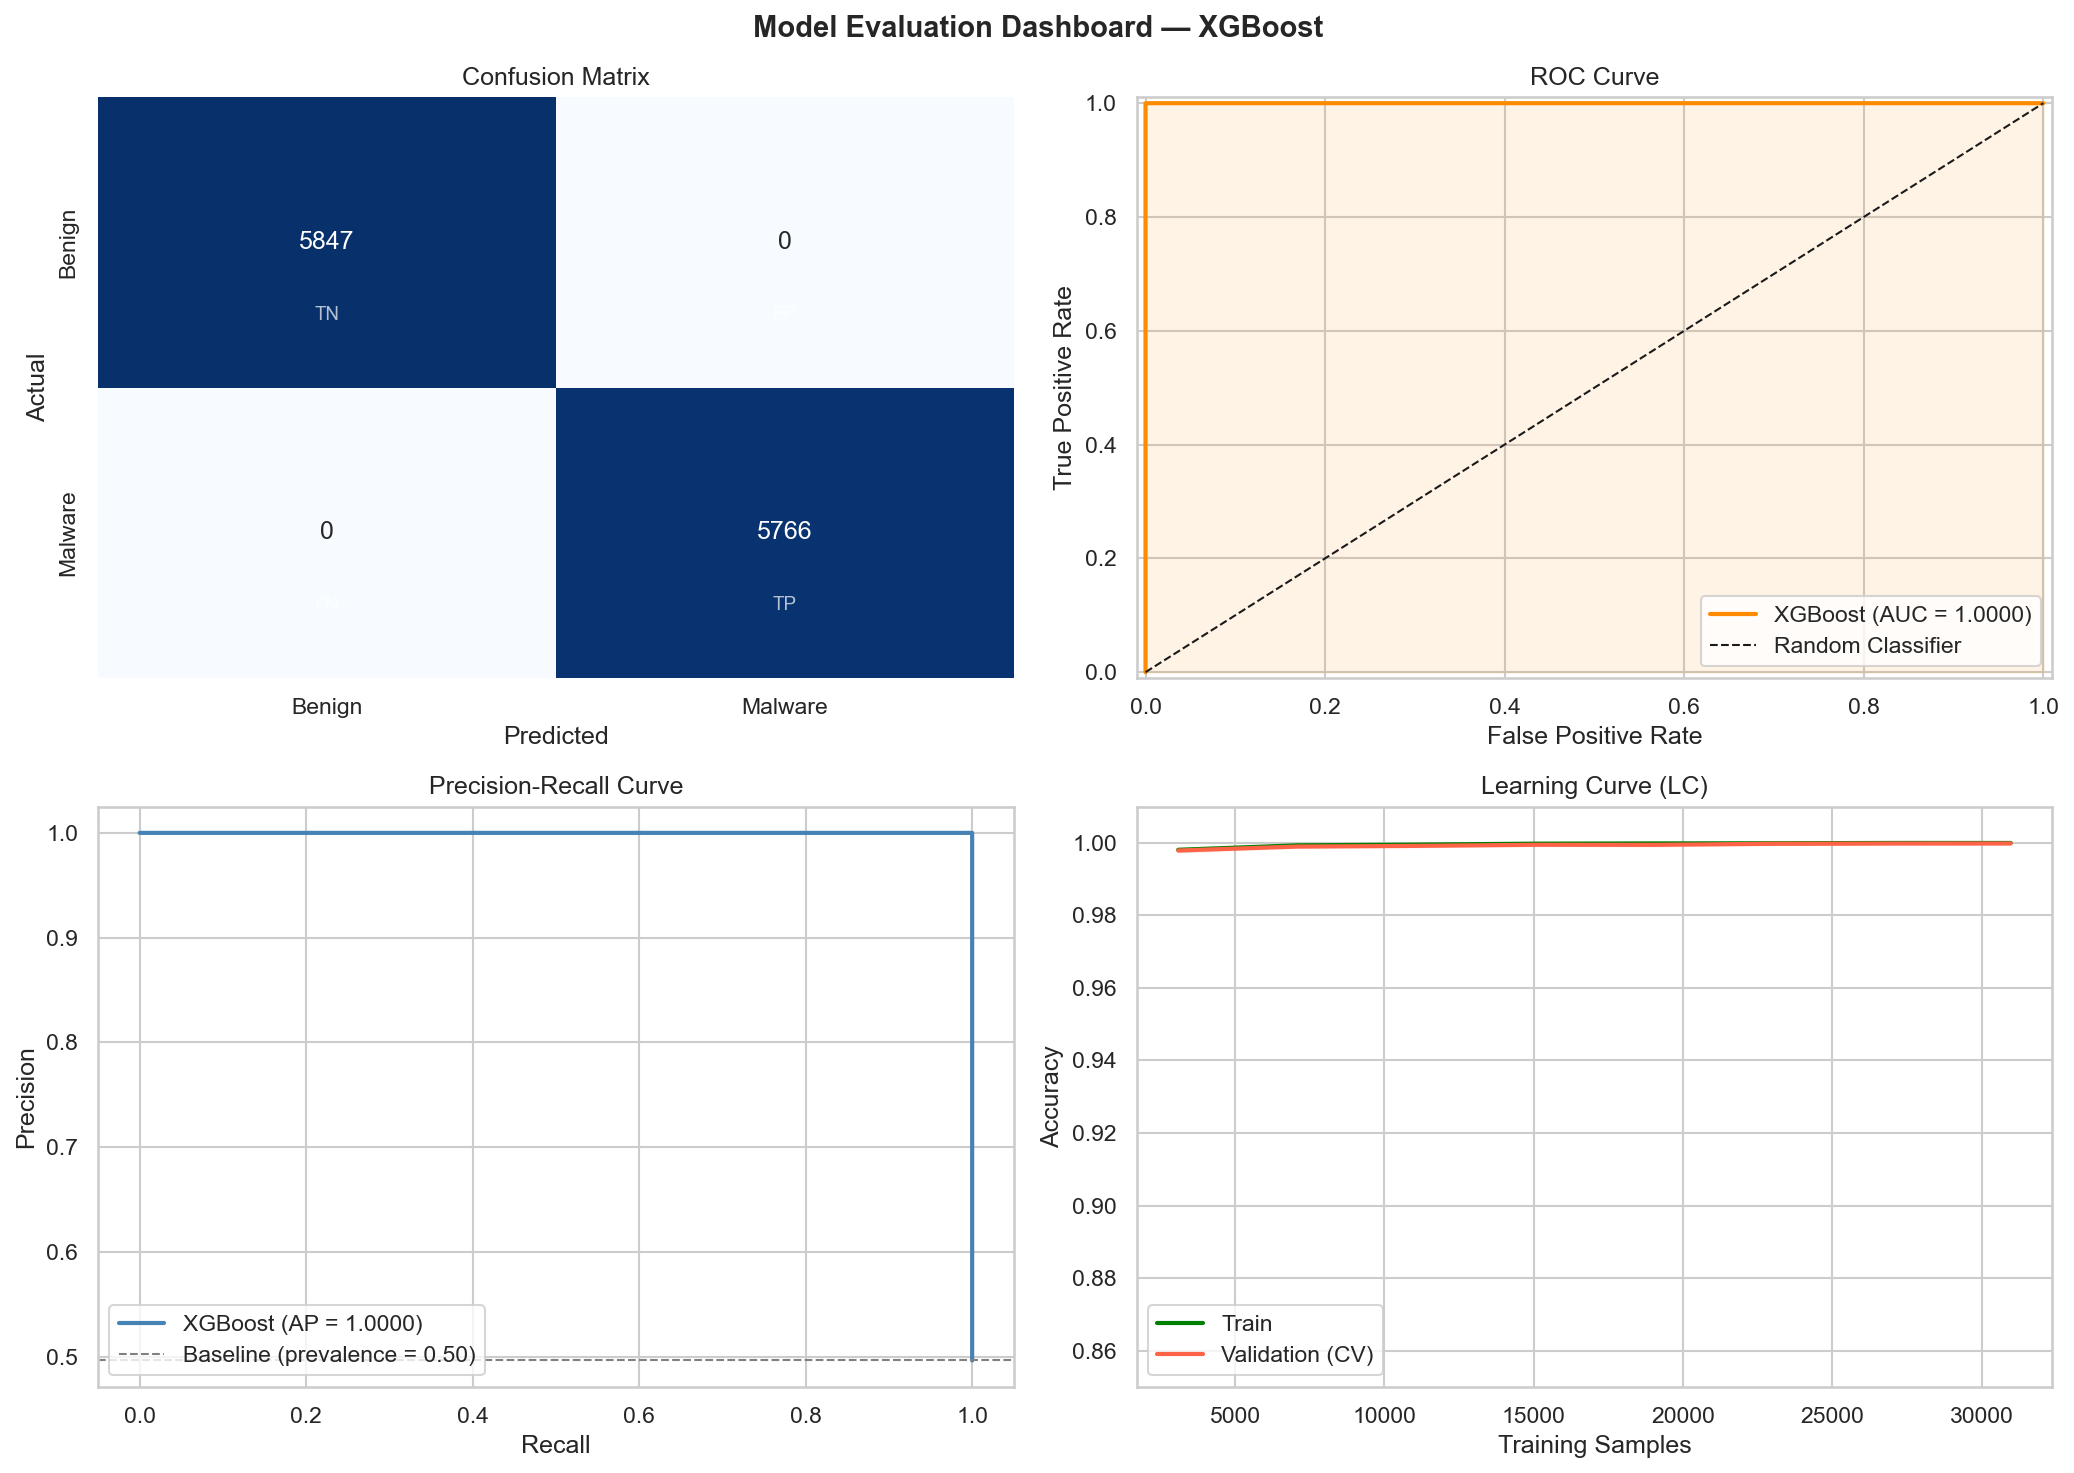

[✓] Evaluation dashboard saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5D — DIAGNOSTIC VISUALIZATIONS
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Precision-Recall Curve
#   4. Learning Curve (LC) — train vs validation accuracy vs training set size
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Dashboard — XGBoost', fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malware'],
    yticklabels=['Benign', 'Malware'],
    ax=axes[0, 0], cbar=False
)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j + 0.5, i + 0.75, labels[i][j],
                        ha='center', va='center', fontsize=9,
                        color='white', alpha=0.7)

# ── Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'XGBoost (AUC = {roc_auc_val:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.01])

# ── Plot 3: Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_proba)
pr_auc_val  = average_precision_score(y_test, y_proba)
baseline_pr = y_test.sum() / len(y_test)
axes[1, 0].plot(recall_arr, precision_arr, color='steelblue', lw=2,
                label=f'XGBoost (AP = {pr_auc_val:.4f})')
axes[1, 0].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                   label=f'Baseline (prevalence = {baseline_pr:.2f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# ── Plot 4: Learning Curve (LC)
#   Shows how accuracy changes as training set size grows
#   Converging train/val lines = good generalisation
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBClassifier(**xgb_params),
    X_train_scaled, y_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)
axes[1, 1].plot(train_sizes, train_scores.mean(axis=1), label='Train', color='green', lw=2)
axes[1, 1].fill_between(train_sizes,
                         train_scores.mean(axis=1) - train_scores.std(axis=1),
                         train_scores.mean(axis=1) + train_scores.std(axis=1),
                         alpha=0.1, color='green')
axes[1, 1].plot(train_sizes, val_scores.mean(axis=1), label='Validation (CV)', color='tomato', lw=2)
axes[1, 1].fill_between(train_sizes,
                         val_scores.mean(axis=1) - val_scores.std(axis=1),
                         val_scores.mean(axis=1) + val_scores.std(axis=1),
                         alpha=0.1, color='tomato')
axes[1, 1].set_xlabel('Training Samples')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Learning Curve (LC)')
axes[1, 1].legend()
axes[1, 1].set_ylim([0.85, 1.01])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evaluation_dashboard.png', bbox_inches='tight')
plt.show()
print('[✓] Evaluation dashboard saved.')

---
## Phase 6 — Explainability (XAI)

### Output Space Clarification [FIX 3]

**SHAP** uses `shap.Explainer` with a tree-based model.  
By default this returns SHAP values in **raw margin space (log-odds)**.  
- Positive SHAP value → feature pushes prediction toward **Malware (class 1)**  
- Negative SHAP value → feature pushes prediction toward **Benign (class 0)**  
- The decomposition satisfies: `model_output = base_value + Σ shap_values`

**LIME** weights are computed for the **predicted class** (Malware=1 or Benign=0).  
- Positive weight → feature **supports** the predicted class  
- Negative weight → feature **contradicts** the predicted class  
- Thresholds are displayed in **original raw feature units** [FIX 4] via inverse-transform

[*] Computing SHAP values in log-odds space...
    (TreeExplainer default: raw margin output, not probability)
[✓] SHAP values computed.
    Base value (expected log-odds): 0.3984


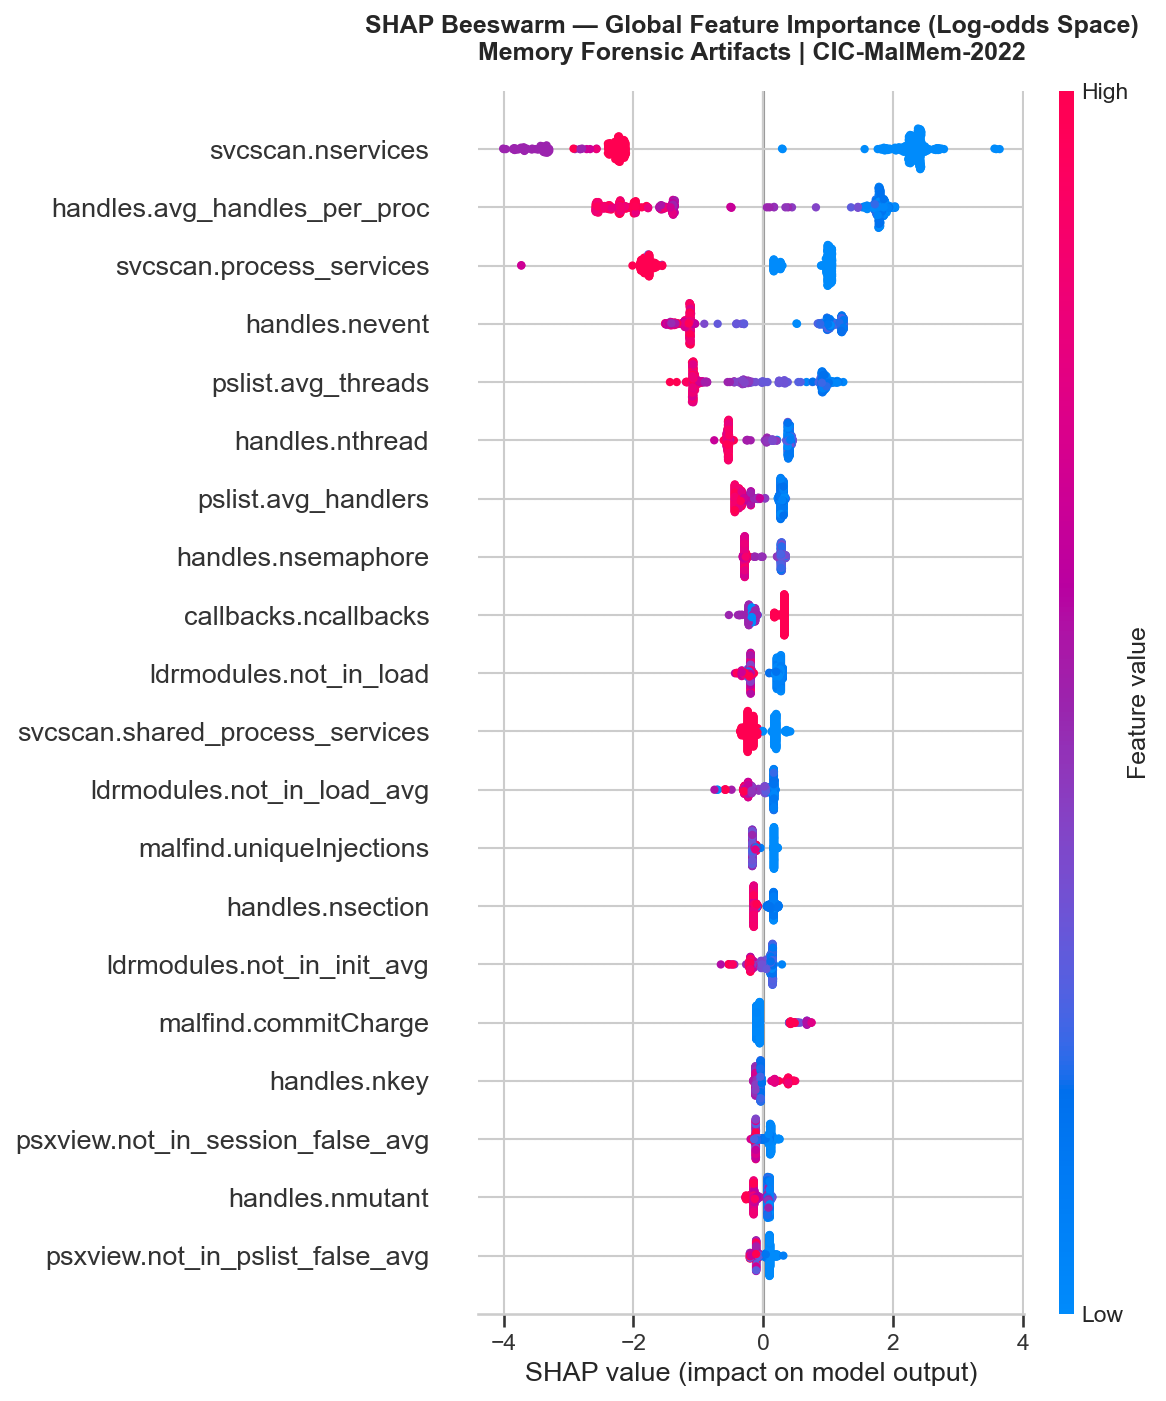

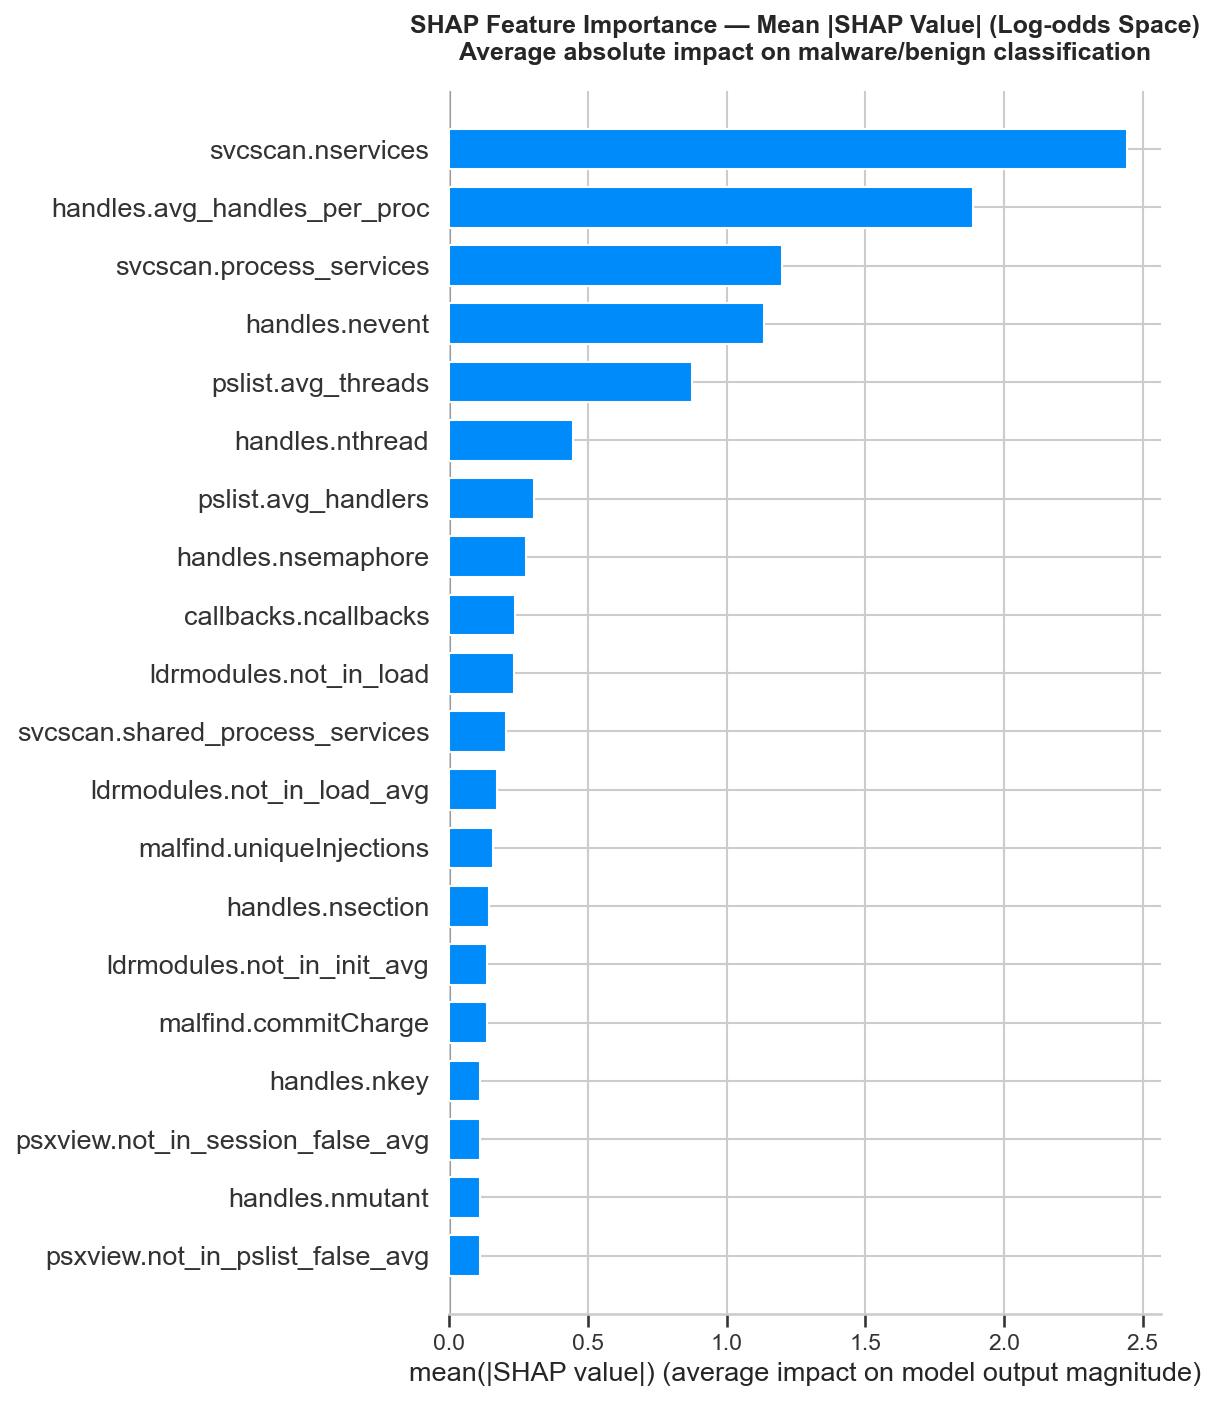

[✓] SHAP plots saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 6A — SHAP: GLOBAL EXPLAINABILITY
#
# Output space: raw margin / log-odds (default for TreeExplainer)
# Positive φ_j → feature j pushes toward Malware class
# Negative φ_j → feature j pushes toward Benign class
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Computing SHAP values in log-odds space...')
print('    (TreeExplainer default: raw margin output, not probability)')

# Sample representative subset for computational efficiency
np.random.seed(RANDOM_STATE)
shap_idx  = np.random.choice(len(X_test_scaled), size=SHAP_SAMPLE, replace=False)
X_shap    = X_test_scaled[shap_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_cols)

shap_explainer = shap.Explainer(xgb_model, X_shap_df)
shap_values    = shap_explainer(X_shap_df)

print('[✓] SHAP values computed.')
print(f'    Base value (expected log-odds): {shap_explainer.expected_value:.4f}')

# ── Figure 1: Beeswarm — global impact distribution per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_df,
    feature_names=feature_cols,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Beeswarm — Global Feature Importance (Log-odds Space)\n'
    'Memory Forensic Artifacts | CIC-MalMem-2022',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_beeswarm.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Bar chart — mean |SHAP| per feature
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap_df,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(
    'SHAP Feature Importance — Mean |SHAP Value| (Log-odds Space)\n'
    'Average absolute impact on malware/benign classification',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}shap_bar.png', bbox_inches='tight')
plt.show()

print('[✓] SHAP plots saved.')

[*] Setting up LIME explainer...


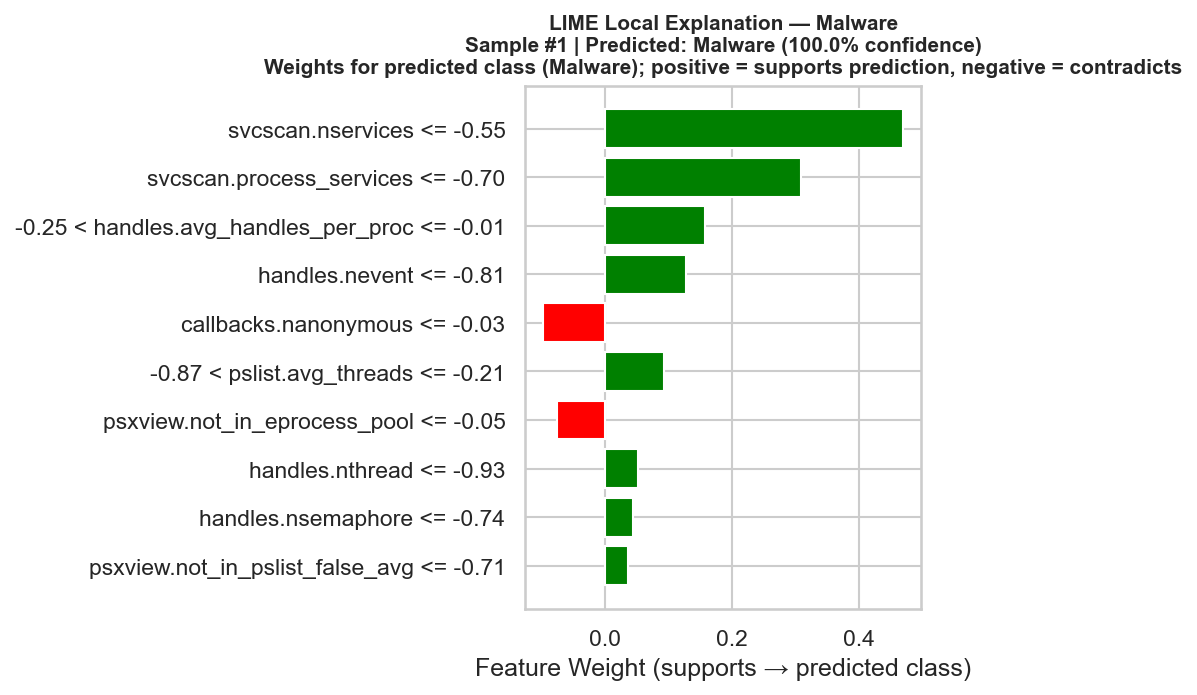


─────────────────────────────────────────────────────────────────
 LIME FORENSIC REPORT — Malware
─────────────────────────────────────────────────────────────────
  Instance        : Test Sample #1
  True Class      : Malware
  Predicted Class : Malware
  Confidence      : 100.00%
  Weights refer to: class "Malware" (predicted class)
  Output space    : probability (predict_proba)

  Feature Rule (Scaled)                    Raw Units                                  Weight
  ──────────────────────────────────────── ──────────────────────────────────────── ────────
  svcscan.nservices <= -0.55               svcscan.nservices <= 389.00               +0.4696  [↑ supports]
  svcscan.process_services <= -0.70        svcscan.process_services <= 24.00         +0.3097  [↑ supports]
  -0.25 < handles.avg_handles_per_proc <= -0.01 209.37 < handles.avg_handles_per_proc <= 248.33  +0.1585  [↑ supports]
  handles.nevent <= -0.81                  handles.nevent <= 2925.35                 +0.1275  

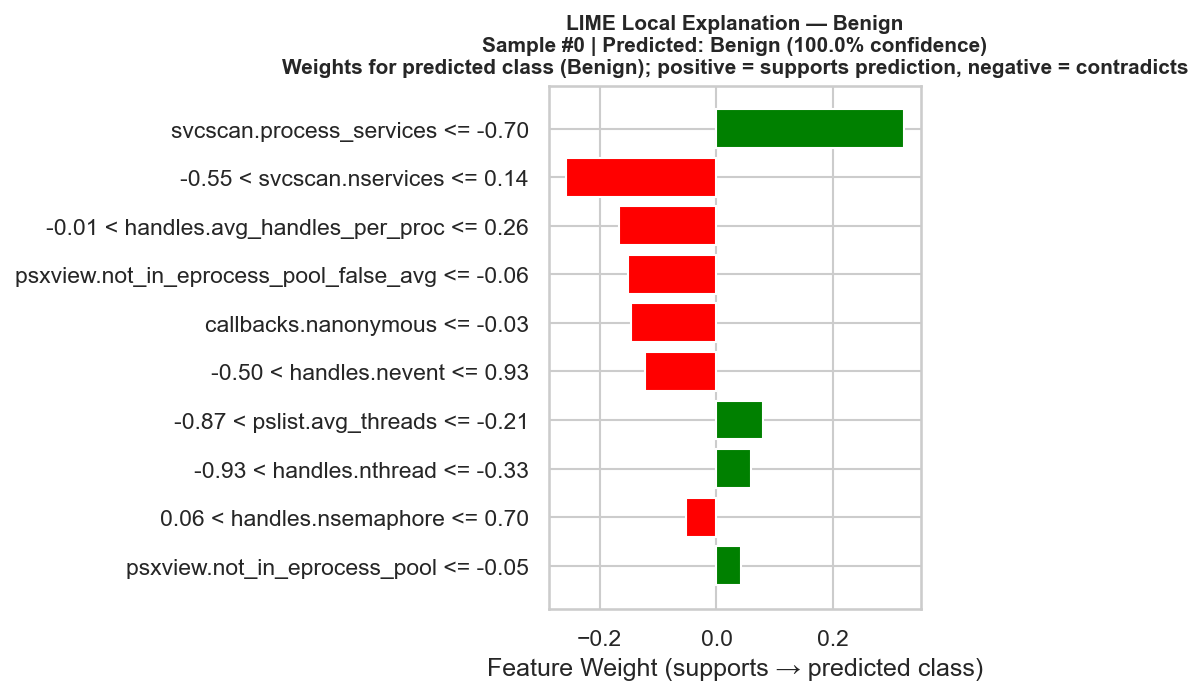


─────────────────────────────────────────────────────────────────
 LIME FORENSIC REPORT — Benign
─────────────────────────────────────────────────────────────────
  Instance        : Test Sample #0
  True Class      : Benign
  Predicted Class : Benign
  Confidence      : 99.99%
  Weights refer to: class "Benign" (predicted class)
  Output space    : probability (predict_proba)

  Feature Rule (Scaled)                    Raw Units                                  Weight
  ──────────────────────────────────────── ──────────────────────────────────────── ────────
  svcscan.process_services <= -0.70        svcscan.process_services <= 24.00         +0.3217  [↑ supports]
  -0.55 < svcscan.nservices <= 0.14        389.00 < svcscan.nservices <= 391.98      -0.2587  [↓ contradicts]
  -0.01 < handles.avg_handles_per_proc <= 0.26 248.33 < handles.avg_handles_per_proc <= 292.15  -0.1667  [↓ contradicts]
  psxview.not_in_eprocess_pool_false_avg <= -0.06 psxview.not_in_eprocess_pool_false_avg <= -0

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6B — LIME: LOCAL EXPLAINABILITY [FIX 4]
#
# LIME weights are for the PREDICTED class.
# Positive weight → feature supports the predicted class.
# Negative weight → feature contradicts the predicted class.
#
# [FIX 4] Thresholds are inverse-transformed back to ORIGINAL FEATURE UNITS
# using: raw_value = scaled_value * std + mean
# This makes the forensic report operationally interpretable.
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Setting up LIME explainer...')

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_cols,
    class_names=['Benign', 'Malware'],
    mode='classification',
    random_state=RANDOM_STATE
)


def inverse_transform_threshold(scaled_threshold_str, feature_means, feature_stds, feature_cols):
    """
    [FIX 4] Convert a LIME threshold string from standardised space back to
    original feature units.

    LIME produces rules like: 'svcscan.nservices <= 0.55'
    We convert 0.55 (standardised) → raw_value = 0.55 * std + mean

    This makes the threshold forensically interpretable (e.g., raw service count).
    """
    import re
    result_lines = []
    for rule, weight in scaled_threshold_str:
        # Try to find a numeric threshold in the rule
        numbers = re.findall(r'[-+]?\d*\.?\d+', rule)
        feat_match = None
        for feat in feature_cols:
            if feat in rule:
                feat_match = feat
                break
        if feat_match and numbers:
            feat_idx = feature_cols.index(feat_match)
            # Convert all thresholds in the rule to raw units
            raw_rule = rule
            for num_str in numbers:
                try:
                    scaled_val = float(num_str)
                    raw_val = scaled_val * feature_stds[feat_idx] + feature_means[feat_idx]
                    raw_rule = raw_rule.replace(num_str, f'{raw_val:.2f}', 1)
                except (ValueError, IndexError):
                    pass
            result_lines.append((rule, raw_rule, weight))
        else:
            result_lines.append((rule, rule, weight))
    return result_lines


def explain_and_plot_lime(sample_index, label_name, output_prefix):
    """Generate, plot, and save a LIME explanation for a single test sample.
    Prints both standardised (scaled) and raw (original-unit) thresholds.
    """
    instance = X_test_scaled[sample_index]

    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=xgb_model.predict_proba,
        num_features=LIME_FEATURES
    )

    # Save HTML (interactive)
    exp.save_to_file(f'{OUTPUT_DIR}{output_prefix}_lime.html')

    # Save static figure
    fig = exp.as_pyplot_figure()
    pred_label  = xgb_model.predict(instance.reshape(1, -1))[0]
    pred_class  = 'Malware' if pred_label == 1 else 'Benign'
    confidence  = np.max(xgb_model.predict_proba(instance.reshape(1, -1))) * 100
    plt.title(
        f'LIME Local Explanation — {label_name}\n'
        f'Sample #{sample_index} | Predicted: {pred_class} ({confidence:.1f}% confidence)\n'
        f'Weights for predicted class ({pred_class}); '
        f'positive = supports prediction, negative = contradicts',
        fontsize=10, fontweight='bold'
    )
    plt.xlabel('Feature Weight (supports → predicted class)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{output_prefix}_lime.png', bbox_inches='tight')
    plt.show()

    # ── Forensic Report
    print(f"\n{'─'*65}")
    print(f' LIME FORENSIC REPORT — {label_name}')
    print(f"{'─'*65}")
    print(f'  Instance        : Test Sample #{sample_index}')
    print(f'  True Class      : {label_name}')
    print(f'  Predicted Class : {pred_class}')
    print(f'  Confidence      : {confidence:.2f}%')
    print(f'  Weights refer to: class "{pred_class}" (predicted class)')
    print(f'  Output space    : probability (predict_proba)')
    print(f"\n  {'Feature Rule (Scaled)':<40} {'Raw Units':<40} {'Weight':>8}")
    print(f"  {'─'*40} {'─'*40} {'─'*8}")

    # [FIX 4] Show both scaled and raw-unit thresholds
    translated = inverse_transform_threshold(
        exp.as_list(), feature_means, feature_stds, feature_cols
    )
    for scaled_rule, raw_rule, weight in translated:
        direction = '↑ supports' if weight > 0 else '↓ contradicts'
        print(f'  {scaled_rule:<40} {raw_rule:<40} {weight:>+8.4f}  [{direction}]')

    print(f"{'─'*65}")


# Explain one confirmed malware and one confirmed benign sample
malware_indices = np.where(y_test == 1)[0]
benign_indices  = np.where(y_test == 0)[0]

explain_and_plot_lime(malware_indices[0], 'Malware', 'malware')
explain_and_plot_lime(benign_indices[0],  'Benign',  'benign')

print('\n[✓] LIME explanations saved (PNG + HTML) with raw-unit thresholds.')

---
## Phase 7 — Model Comparison

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPARE XGBoost AGAINST BASELINE CLASSIFIERS
#   1. XGBoost          (proposed model)
#   2. Random Forest    (tree-based baseline)
#   3. Gradient Boosting
#   4. MLP              (neural network baseline)
#   5. Logistic Regression (linear baseline)
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Running model comparison...')

comparison_models = {
    'XGBoost (Proposed)' : xgb_model,
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.05,
                                                       random_state=RANDOM_STATE),
    'MLP (Neural Net)'   : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                          random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results_list = []
fig, ax = plt.subplots(figsize=(10, 6))

for name, mdl in comparison_models.items():
    print(f'  → Training: {name}')
    if name != 'XGBoost (Proposed)':
        mdl.fit(X_train_scaled, y_train)

    preds_m = mdl.predict(X_test_scaled)
    probs_m = mdl.predict_proba(X_test_scaled)[:, 1]

    fpr_m, tpr_m, _ = roc_curve(y_test, probs_m)
    auc_m  = auc(fpr_m, tpr_m)
    acc_m  = accuracy_score(y_test, preds_m)
    f1_m   = f1_score(y_test, preds_m)
    mcc_m  = matthews_corrcoef(y_test, preds_m)

    results_list.append({
        'Model'    : name,
        'Accuracy' : round(acc_m, 4),
        'F1-Score' : round(f1_m, 4),
        'ROC-AUC'  : round(auc_m, 4),
        'MCC'      : round(mcc_m, 4),
    })

    ls = '-' if name == 'XGBoost (Proposed)' else '--'
    ax.plot(fpr_m, tpr_m, lw=2, linestyle=ls,
            label=f'{name} (AUC={auc_m:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_comparison_roc.png', bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print('\n' + '=' * 65)
print('  MODEL COMPARISON — HOLD-OUT TEST SET')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)

results_df.to_csv(f'{OUTPUT_DIR}model_comparison.csv', index=False)
print('[✓] Comparison table saved.')

[*] Running model comparison...
  → Training: XGBoost (Proposed)
  → Training: Random Forest
  → Training: Gradient Boosting


---
## Phase 8 — Data Integrity & Leakage Audit

### Three audit stages:

| Stage | What it checks |
|-------|----------------|
| **Audit 1** | Exact train/test sample overlap on the *post-clean* split |
| **Audit 2** | Feature–target Pearson correlation (|r| > 0.95 threshold) |
| **Audit 3** | Permutation significance test (n=1000, p < 0.05) |

> **[FIX 2] Chronology note:**  
> Duplicate removal is applied *before* the split (Phase 3).  
> Therefore Audit 1 operates on the post-clean data and should yield **zero overlap**  
> for exact bitwise duplicates. Any residual overlap indicates near-duplicates  
> (identical feature values that survived the deduplication hash).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 1 — TRAIN/TEST SAMPLE OVERLAP  [FIX 2]
#
# We check BOTH:
#   (a) Raw dataset: how many duplicates existed before cleaning
#   (b) Post-clean split: how many exact samples appear in both train AND test
#
# Correct denominator for % is stated explicitly to avoid the
# reviewer-identified error (10/58062 ≠ 10/11613).
# ─────────────────────────────────────────────────────────────────────────────

print('[Audit 1 — Train/Test Overlap]')
print(f'  Context: duplicates were removed from the raw data BEFORE the split.')
print(f'  Raw dataset had {df_raw.duplicated().sum()} duplicate rows (now removed).')
print()

# Check post-clean split overlap (unscaled, to avoid float rounding artefacts)
train_set_raw = set(map(tuple, X_train.tolist()))
test_set_raw  = set(map(tuple, X_test.tolist()))
overlap_raw   = train_set_raw.intersection(test_set_raw)

n_overlap        = len(overlap_raw)
pct_of_test      = n_overlap / len(X_test)  * 100
pct_of_cleaned   = n_overlap / len(X)       * 100

print(f'  Post-clean overlap (exact bitwise match):')
print(f'    Overlapping samples : {n_overlap}')
print(f'    As % of test set    : {pct_of_test:.3f}%  ({n_overlap}/{len(X_test):,})')
print(f'    As % of full dataset: {pct_of_cleaned:.3f}%  ({n_overlap}/{len(X):,})')

if n_overlap == 0:
    print('  [✓] PASS — Zero overlap after deduplication. Pipeline is consistent.')
else:
    print(f'  [⚠️  WARN] — {n_overlap} near-duplicate samples span the split boundary.')
    print('    These are float-identical rows that survived the string-hash deduplication.')
    print('    Scale of impact is negligible but should be disclosed.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 2 — FEATURE-TARGET CORRELATION
#
# Pearson |r| > 0.95 may indicate a single feature is a near-proxy for the
# target label, which would make the problem trivially easy without the model
# learning a genuine joint distribution.
#
# Note: a feature with |r| = 0.90 can still be a legitimate forensic artefact
# that is genuinely discriminative in real memory dumps.
# The threshold is a screening heuristic, not a definitive leakage proof.
# ─────────────────────────────────────────────────────────────────────────────

print('[Audit 2 — Feature-Target Correlation]')
print('  Computed on RAW dataset (before cleaning) for full dataset coverage.')
print(f'  Leakage screening threshold: |r| > 0.95')
print()

leakage_suspects = correlations[correlations > 0.95].index.tolist()
max_corr_feat    = correlations.index[0]
max_corr_val     = correlations.iloc[0]

print(f'  Maximum |r|: {max_corr_val:.4f}  (feature: {max_corr_feat})')

if leakage_suspects:
    print(f'  [⚠️  WARNING] {len(leakage_suspects)} features with |r| > 0.95:')
    for f in leakage_suspects:
        print(f'    → {f}  (|r| = {correlations[f]:.4f})')
    print('  These may be genuine forensic discriminators but warrant disclosure.')
else:
    print('  [✓] PASS — No features with |r| > 0.95 detected.')
    print('  Note: correlation heuristic does not rule out multivariate proxy leakage.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUDIT 3 — PERMUTATION SIGNIFICANCE TEST  [FIX 1]
#
# Tests whether the model's accuracy on real labels is significantly better
# than on randomly permuted labels.
#
# [FIX 1] Key changes from v2:
#   - n_permutations : 20  →  1000  (much more reliable p-value resolution)
#   - p-value formula: (# permutations >= real_score + 1) / (n_permutations + 1)
#     This is the standard unbiased plus-one correction (Phipson & Smyth, 2010)
#   - Seed and CV folds are documented explicitly for reproducibility
#
# With n=1000, the minimum achievable p-value is 1/1001 ≈ 0.001
# (compared to 1/21 ≈ 0.048 with n=20)
#
# WARNING: This cell may take 10-30 minutes depending on hardware.
# ─────────────────────────────────────────────────────────────────────────────

print(f'[Audit 3 — Permutation Significance Test]')
print(f'  n_permutations : {N_PERMUTATIONS}  (from config — reviewer fix applied)')
print(f'  CV folds       : 3  (fast inner CV for permuted models)')
print(f'  Random seed    : {RANDOM_STATE}')
print(f'  Scoring metric : accuracy')
print(f'  p-value formula: (# perms >= score + 1) / (n_perms + 1)  [plus-one correction]')
print(f'  ⏳ Running... (this may take several minutes)')
print()

perm_model = xgb.XGBClassifier(
    n_estimators = 100,
    max_depth    = 4,
    eval_metric  = 'logloss',
    random_state = RANDOM_STATE
)

real_score, perm_scores, p_value = permutation_test_score(
    perm_model,
    X_train_scaled, y_train,
    cv              = 3,
    n_permutations  = N_PERMUTATIONS,
    scoring         = 'accuracy',
    random_state    = RANDOM_STATE,
    n_jobs          = -1
)

print(f'  Real model accuracy  : {real_score:.4f}')
print(f'  Permuted mean ± std  : {perm_scores.mean():.4f} ± {perm_scores.std():.4f}')
print(f'  Permuted range       : [{perm_scores.min():.4f}, {perm_scores.max():.4f}]')
print(f'  p-value              : {p_value:.4f}  (n={N_PERMUTATIONS}, plus-one correction)')
print()

if p_value < 0.001:
    print(f'  [✓] STRONG PASS — p < 0.001. Real signal confirmed with high confidence.')
elif p_value < 0.01:
    print(f'  [✓] PASS — p < 0.01. Real signal confirmed.')
elif p_value < 0.05:
    print(f'  [✓] PASS — p < 0.05. Real signal confirmed (standard significance level).')
else:
    print(f'  [⚠️  WARNING] — p ≥ 0.05. Results are not statistically significant.')

# Save permutation distribution plot
plt.figure(figsize=(8, 4))
plt.hist(perm_scores, bins=30, color='steelblue', edgecolor='white', alpha=0.8,
         label=f'Permuted scores (n={N_PERMUTATIONS})')
plt.axvline(x=real_score, color='red', lw=2, linestyle='--',
            label=f'Real model score: {real_score:.4f}')
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.title(f'Permutation Test Distribution (p = {p_value:.4f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}permutation_test.png', bbox_inches='tight')
plt.show()

print('[✓] Leakage audit complete.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# NOISE ROBUSTNESS TEST  [FIX 5]
#
# This test evaluates model accuracy under synthetic Gaussian feature
# perturbation — NOT operational memory-acquisition noise.
#
# [FIX 5] Language corrected: we no longer claim this represents
# 'real-world measurement noise'. It is a controlled perturbation test
# that assesses sensitivity to independent Gaussian feature noise.
# Robustness to real-world acquisition noise, parser instability, or
# adversarial variation would require domain-specific noise models.
# ─────────────────────────────────────────────────────────────────────────────

print('[*] Synthetic Feature Perturbation Test...')
print('    (Gaussian noise added to standardised features — see note above)')

noise_levels = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
noise_results = []

for sigma in noise_levels:
    rng = np.random.default_rng(RANDOM_STATE)
    X_noisy     = X_test_scaled + rng.normal(0, sigma, X_test_scaled.shape)
    noisy_preds = xgb_model.predict(X_noisy)
    noisy_acc   = accuracy_score(y_test, noisy_preds)
    noise_results.append({'Noise σ': sigma, 'Accuracy': noisy_acc})
    print(f'  σ = {sigma:.3f} → Accuracy: {noisy_acc:.4f}')

noise_df = pd.DataFrame(noise_results)

plt.figure(figsize=(8, 4))
plt.plot(noise_df['Noise σ'], noise_df['Accuracy'], 'o-', color='steelblue', lw=2)
plt.axhline(y=test_acc, color='gray', linestyle='--',
            label=f'Clean baseline ({test_acc:.4f})')
plt.xlabel('Gaussian Noise σ (applied to standardised features)')
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Under Synthetic Feature Perturbation', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}noise_robustness.png', bbox_inches='tight')
plt.show()

print('[✓] Synthetic perturbation test complete.')

---
## Phase 9 — Artifact Export

In [ ]:
print('[*] Saving all artifacts...')

# Model & Scaler
joblib.dump(xgb_model, f'{OUTPUT_DIR}xgboost_malware_model.pkl')
joblib.dump(scaler,    f'{OUTPUT_DIR}standard_scaler.pkl')

# SHAP values
np.save(f'{OUTPUT_DIR}shap_values.npy', shap_values.values)
pd.DataFrame(X_shap, columns=feature_cols).to_csv(f'{OUTPUT_DIR}shap_sample.csv', index=False)

# Test-set predictions
test_export = pd.DataFrame({
    'True_Label'     : ['Malware' if l == 1 else 'Benign' for l in y_test],
    'Predicted_Label': ['Malware' if p == 1 else 'Benign' for p in y_pred],
    'Malware_Prob'   : y_proba,
    'Correct'        : (y_test == y_pred)
})
test_export.to_csv(f'{OUTPUT_DIR}test_predictions.csv', index=False)

# Feature importance
feat_importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_importance_df.to_csv(f'{OUTPUT_DIR}feature_importance.csv', index=False)

# Metrics summary
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f'{OUTPUT_DIR}metrics_summary.csv', index=False)

# Permutation test results
perm_df = pd.DataFrame({
    'real_score'   : [real_score],
    'perm_mean'    : [perm_scores.mean()],
    'perm_std'     : [perm_scores.std()],
    'p_value'      : [p_value],
    'n_permutations': [N_PERMUTATIONS]
})
perm_df.to_csv(f'{OUTPUT_DIR}permutation_test_results.csv', index=False)

# Noise robustness
noise_df.to_csv(f'{OUTPUT_DIR}noise_robustness_results.csv', index=False)

# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═' * 60)
print('  PIPELINE COMPLETE — FINAL SUMMARY (v3)')
print('═' * 60)
print(f'  Dataset        : CIC-MalMem-2022')
print(f'  Total Samples  : {len(df):,}  (train: {len(X_train):,} | test: {len(X_test):,})')
print(f'  Features Used  : {len(feature_cols)}')
print()
for metric, value in metrics.items():
    print(f'  {metric:<25}: {value:.4f}')
print()
print(f'  Permutation p-value : {p_value:.4f}  (n={N_PERMUTATIONS} permutations)')
print(f'  XAI Methods         : SHAP (global, log-odds) + LIME (local, raw units)')
print(f'  Models Compared     : {len(comparison_models)}')
print(f'  Output Dir          : {os.path.abspath(OUTPUT_DIR)}')
print('═' * 60)

artifacts = [
    'xgboost_malware_model.pkl', 'standard_scaler.pkl',
    'shap_values.npy', 'shap_sample.csv',
    'test_predictions.csv', 'feature_importance.csv',
    'metrics_summary.csv', 'model_comparison.csv',
    'permutation_test_results.csv', 'noise_robustness_results.csv',
    'eda_dashboard.png', 'evaluation_dashboard.png',
    'shap_beeswarm.png', 'shap_bar.png',
    'malware_lime.png', 'malware_lime.html',
    'benign_lime.png',  'benign_lime.html',
    'model_comparison_roc.png', 'noise_robustness.png',
    'permutation_test.png',
]

print('\n  Saved Artifacts:')
for artifact in artifacts:
    path   = f'{OUTPUT_DIR}{artifact}'
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  [{status}] {artifact}')